## Actividad ED.01.02 - Git, GitHub y reproducibilidad
**Nombre:** Daniel Ruvalcaba Juárez
**Matrícula:** 126058326
**Grupo:** IDIA222
**Materia:** Manejo Masivo de Datos
**Dataset:** Students Performance (Kaggle)

En este notebook voy a hacer el análisis y preprocesamiento del dataset que me tocó,
siguiendo los mismos pasos que hemos usado en clase.

## Paso 1: Importar los datos

El dataset es un `.csv` normal separado por comas, así que lo puedo leer directo con `read_csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Paso 2: Exploración inicial

Reviso cuántas filas y columnas tiene, los nombres de las columnas y el tipo de dato de cada una.

In [2]:
print(df.shape)

(1000, 8)


Tenemos 1000 filas y 8 columnas. Ahora reviso los nombres.

In [3]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

Los nombres de las columnas tienen espacios y una tiene `/` (`race/ethnicity`), no están tan
estandarizados, pero como son pocas columnas los puedo dejar así y solo tener cuidado al escribirlos entre comillas.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


Con `df.info()` puedo ver que no hay ningún valor nulo (todas las columnas tienen 1000 valores non-null)
y que son 3 columnas numéricas (las calificaciones) y 5 columnas de tipo texto (`object`).

## Paso 3: Revisión de estructura

Reviso si hay columnas o filas duplicadas.

In [5]:
print("Columnas duplicadas:", df.columns.duplicated().sum())
print("Filas duplicadas:", df.duplicated().sum())

Columnas duplicadas: 0
Filas duplicadas: 0


No hay columnas ni filas duplicadas, así que no tengo que quitar nada aquí.

## Paso 4: Valores nulos

Aunque ya vi en el `info()` que no había nulos, lo confirmo con `isnull().sum()` por si se me pasó algo.

In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Confirmado, no hay ni un solo valor nulo en ninguna columna, entonces no necesito imputar ni quitar filas.

## Paso 5: Explorando las variables categóricas

Antes de preprocesar quiero ver cómo se distribuyen las variables de tipo texto, para entender un poco el dataset.

In [7]:
columnas_categoricas = ["gender", "race/ethnicity", "parental level of education", "lunch", "test preparation course"]

for columna in columnas_categoricas:
    print(f"--- {columna} ---")
    print(df[columna].value_counts())
    print()

--- gender ---
gender
female    518
male      482
Name: count, dtype: int64

--- race/ethnicity ---
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

--- parental level of education ---
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

--- lunch ---
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

--- test preparation course ---
test preparation course
none         642
completed    358
Name: count, dtype: int64



Se ve bastante parejo entre hombres y mujeres, la mayoría tiene comida `standard` y la mayoría
**no** completó el curso de preparación para el examen.

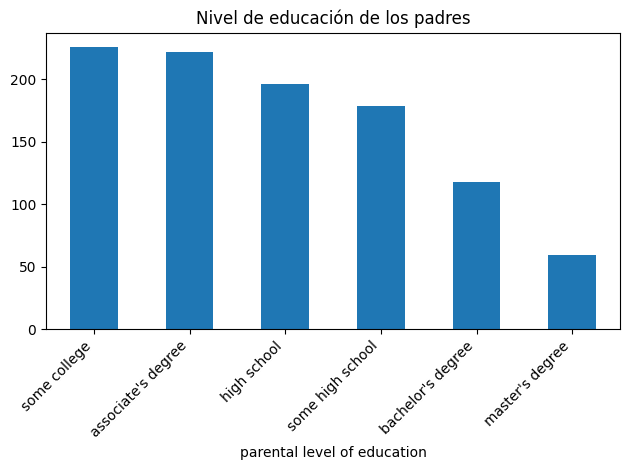

In [8]:
df["parental level of education"].value_counts().plot(kind="bar")
plt.title("Nivel de educación de los padres")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Paso 6: Explorando las calificaciones

Ahora reviso las 3 columnas numéricas (math score, reading score, writing score) con `describe()`
y con un histograma para ver cómo se distribuyen.

In [9]:
columnas_numericas = ["math score", "reading score", "writing score"]
df[columnas_numericas].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


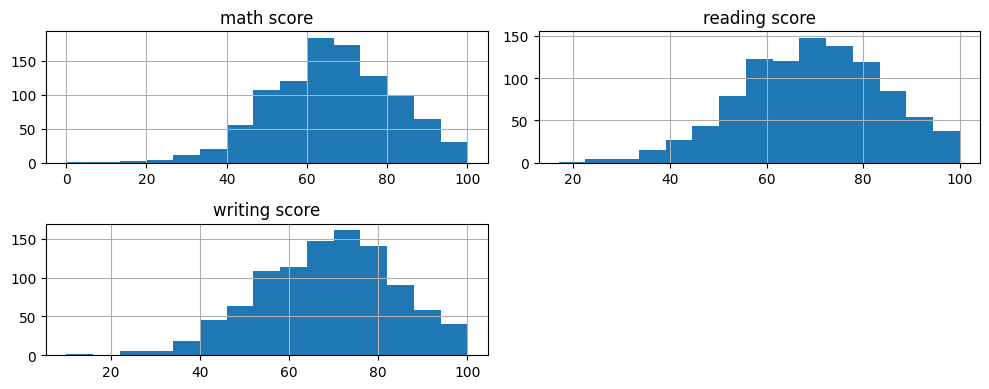

In [10]:
df[columnas_numericas].hist(bins=15, figsize=(10, 4))
plt.tight_layout()
plt.show()

Las tres calificaciones se ven más o menos con forma de campana, centradas entre 65 y 70 puntos.

## Paso 7: Detección de valores atípicos (outliers)

Uso el método de rango intercuartílico (IQR) que vimos en clase: todo lo que caiga fuera de
`Q1 - 1.5*IQR` y `Q3 + 1.5*IQR` lo cuento como outlier.

In [11]:
for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    print(f"{columna}: {len(outliers)} outliers (límites: {limite_inferior:.1f} - {limite_superior:.1f})")

math score: 8 outliers (límites: 27.0 - 107.0)
reading score: 6 outliers (límites: 29.0 - 109.0)
writing score: 5 outliers (límites: 25.9 - 110.9)


Solo `math score` tiene un par de outliers, calificaciones muy bajas. Como son pocos y son
calificaciones reales (no errores de captura obvios), decidí dejarlos tal cual y no eliminarlos.

## Paso 8: Creando una columna nueva (feature engineering)

Se me ocurrió sacar el promedio de las 3 calificaciones, para tener un solo número que resuma
qué tan bien le fue a cada estudiante.

In [12]:
df["promedio_calificaciones"] = df[columnas_numericas].mean(axis=1).round(2)
df[["math score", "reading score", "writing score", "promedio_calificaciones"]].head()

,math score,reading score,writing score,promedio_calificaciones
0,72,72,74,72.67
1,69,90,88,82.33
2,90,95,93,92.67
3,47,57,44,49.33
4,76,78,75,76.33


## Paso 9: Codificando las variables categóricas

Para que el dataset se pueda usar después en algún modelo, convierto las columnas de texto en
columnas numéricas usando `get_dummies` (one-hot encoding).

In [13]:
df_codificado = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)
df_codificado.head()

,math score,reading score,writing score,promedio_calificaciones,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,72.67,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,82.33,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,92.67,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,49.33,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,76.33,True,False,True,False,False,False,False,False,True,False,True,True


## Paso 10: Guardar el dataset preprocesado

Por último guardo el dataframe ya con la columna nueva y las variables codificadas, para dejar
evidencia del preprocesamiento.

In [14]:
df_codificado.to_csv("../data/StudentsPerformance_procesado.csv", index=False)
print("Guardado en data/StudentsPerformance_procesado.csv")
print("Dimensiones finales:", df_codificado.shape)

Guardado en data/StudentsPerformance_procesado.csv
Dimensiones finales: (1000, 16)


## Conclusión

El dataset ya venía bastante limpio (sin nulos ni duplicados), así que el trabajo principal fue
explorar las variables, detectar los pocos outliers en `math score` y dejar los datos codificados
y con la columna de promedio, listos para usarse después.